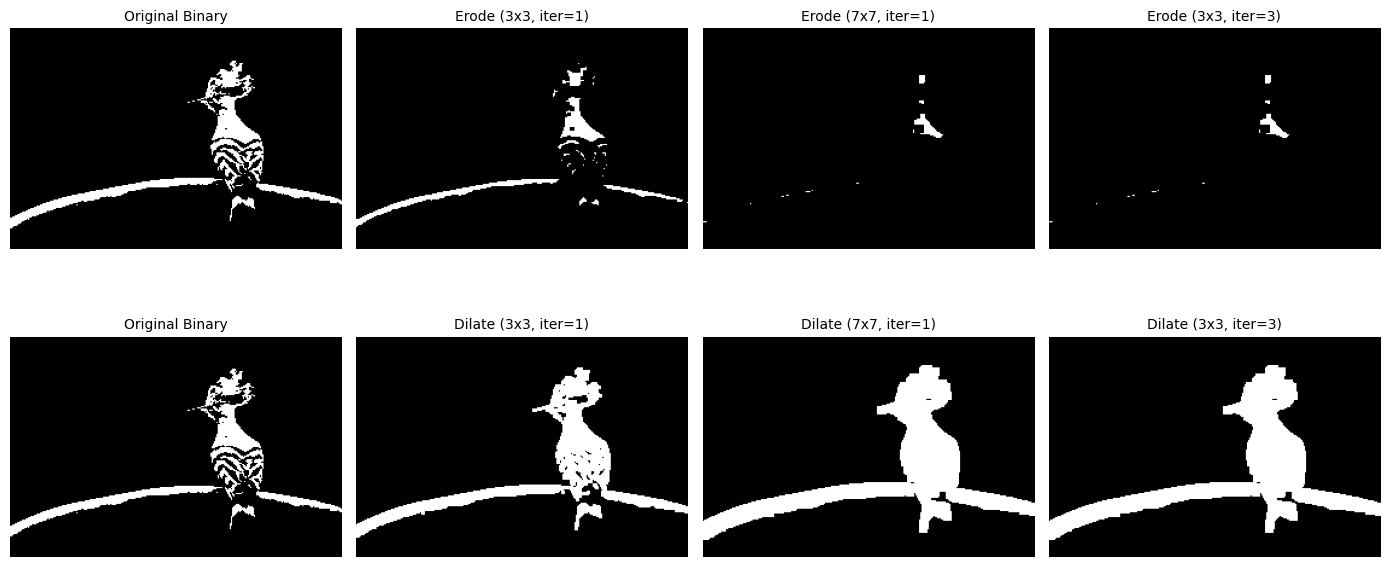

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('/content/Bird.jpg', cv2.IMREAD_GRAYSCALE)

_, binary_img1 = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)

kernel_3x3 = np.ones((3, 3), np.uint8)
kernel_7x7 = np.ones((7, 7), np.uint8)

eroded_k3_it1 = cv2.erode(binary_img1, kernel_3x3, iterations=1)
eroded_k7_it1 = cv2.erode(binary_img1, kernel_7x7, iterations=1)
eroded_k3_it3 = cv2.erode(binary_img1, kernel_3x3, iterations=3)

dilated_k3_it1 = cv2.dilate(binary_img1, kernel_3x3, iterations=1)
dilated_k7_it1 = cv2.dilate(binary_img1, kernel_7x7, iterations=1)
dilated_k3_it3 = cv2.dilate(binary_img1, kernel_3x3, iterations=3)

titles = [
    'Original Binary', 'Erode (3x3, iter=1)', 'Erode (7x7, iter=1)', 'Erode (3x3, iter=3)',
    'Original Binary', 'Dilate (3x3, iter=1)', 'Dilate (7x7, iter=1)', 'Dilate (3x3, iter=3)'
]
images = [
    binary_img1, eroded_k3_it1, eroded_k7_it1, eroded_k3_it3,
    binary_img1, dilated_k3_it1, dilated_k7_it1, dilated_k3_it3
]

plt.figure(figsize=(14, 7))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

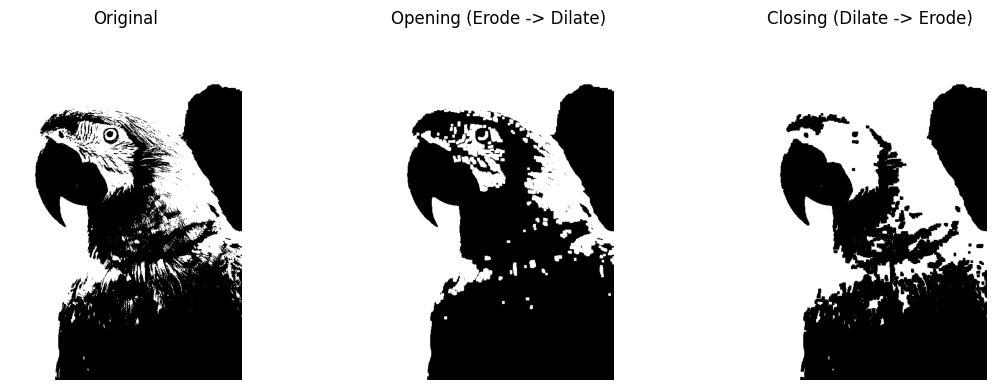

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img2 = cv2.imread('/content/Parrot.jpg', cv2.IMREAD_GRAYSCALE)

_, binary_img2 = cv2.threshold(img2, 127, 255, cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

opening = cv2.morphologyEx(binary_img2, cv2.MORPH_OPEN, kernel)

closing = cv2.morphologyEx(binary_img2, cv2.MORPH_CLOSE, kernel)

titles_task2 = ['Original', 'Opening (Erode -> Dilate)', 'Closing (Dilate -> Erode)']
images_task2 = [binary_img2, opening, closing]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images_task2[i], cmap='gray')
    plt.title(titles_task2[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

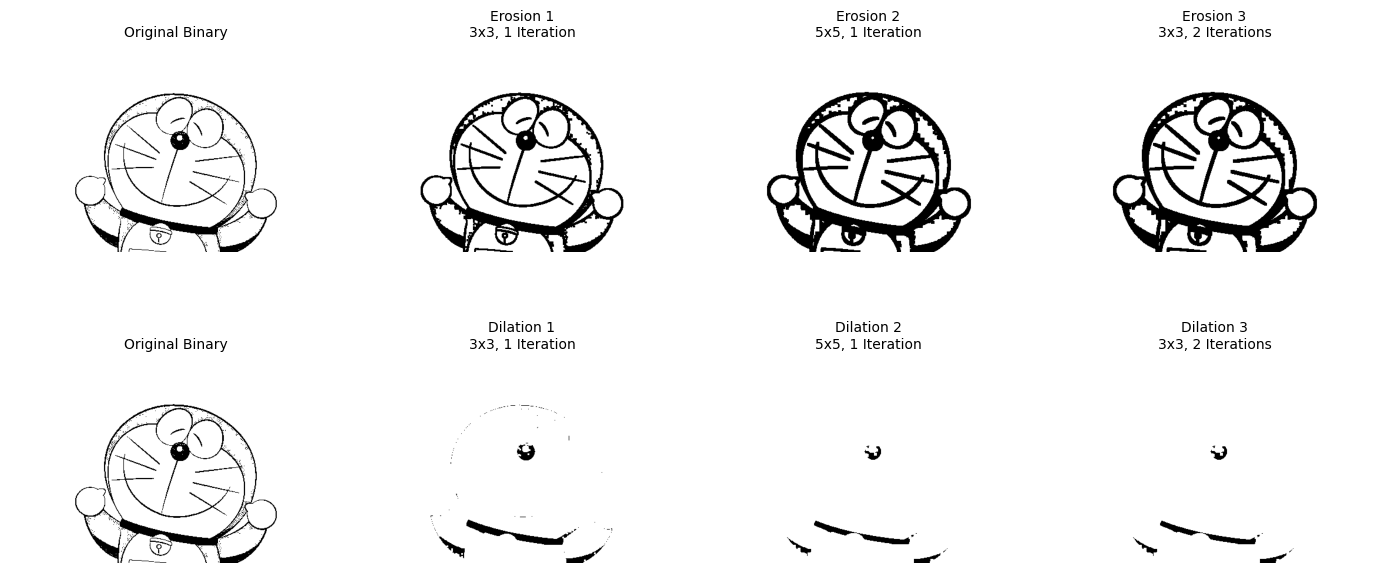

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Read input image and convert to binary
source_img1 = cv2.imread('/content/Cartoon.jpg', cv2.IMREAD_GRAYSCALE)

_, binary_mask1 = cv2.threshold(
    source_img1, 120, 255, cv2.THRESH_BINARY
)

# Save binary/original image
cv2.imwrite('/content/Cartoon1.jpg', binary_mask1)

# 2. Setup structuring elements
small_elem = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
medium_elem = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

# 3. Erosion experiments
erode_step1 = cv2.erode(binary_mask1, small_elem, iterations=1)
erode_step2 = cv2.erode(binary_mask1, medium_elem, iterations=1)
erode_step3 = cv2.erode(binary_mask1, small_elem, iterations=2)

# Save erosion results
cv2.imwrite('/content/erosion_1_3x3_1iteration.png', erode_step1)
cv2.imwrite('/content/erosion_2_5x5_1iteration.png', erode_step2)
cv2.imwrite('/content/erosion_3_3x3_2iterations.png', erode_step3)

# 4. Dilation experiments
dilate_step1 = cv2.dilate(binary_mask1, small_elem, iterations=1)
dilate_step2 = cv2.dilate(binary_mask1, medium_elem, iterations=1)
dilate_step3 = cv2.dilate(binary_mask1, small_elem, iterations=2)

# Save dilation results
cv2.imwrite('/content/dilation_1_3x3_1iteration.png', dilate_step1)
cv2.imwrite('/content/dilation_2_5x5_1iteration.png', dilate_step2)
cv2.imwrite('/content/dilation_3_3x3_2iterations.png', dilate_step3)

# 5. Visual comparison
grid_images = [
    [binary_mask1, erode_step1, erode_step2, erode_step3],
    [binary_mask1, dilate_step1, dilate_step2, dilate_step3]
]

grid_labels = [
    [
        "Original Binary",
        "Erosion 1\n3x3, 1 Iteration",
        "Erosion 2\n5x5, 1 Iteration",
        "Erosion 3\n3x3, 2 Iterations"
    ],
    [
        "Original Binary",
        "Dilation 1\n3x3, 1 Iteration",
        "Dilation 2\n5x5, 1 Iteration",
        "Dilation 3\n3x3, 2 Iterations"
    ]
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for row in range(2):
    for col in range(4):
        axes[row, col].imshow(
            grid_images[row][col],
            cmap='gray'
        )
        axes[row, col].set_title(
            grid_labels[row][col],
            fontsize=10
        )
        axes[row, col].axis('off')

plt.tight_layout()

# Save comparison image
plt.savefig(
    '/content/erosion_dilation_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# 6. Download all generated images
files.download('/content/original_binary.png')
files.download('/content/erosion_1_3x3_1iteration.png')
files.download('/content/erosion_2_5x5_1iteration.png')
files.download('/content/erosion_3_3x3_2iterations.png')
files.download('/content/dilation_1_3x3_1iteration.png')
files.download('/content/dilation_2_5x5_1iteration.png')
files.download('/content/dilation_3_3x3_2iterations.png')
files.download('/content/erosion_dilation_comparison.png')

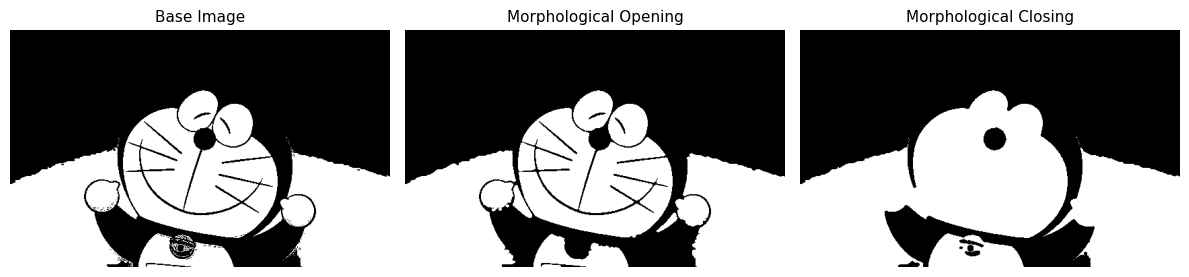

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load an image with text, fingerprints, or fragmented patterns
source_img2 = cv2.imread('/content/Cartoon.jpg', cv2.IMREAD_GRAYSCALE)
_, binary_mask2 = cv2.threshold(source_img2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Create non-square / elliptical structuring element
kernel_shape = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# 3. Apply Opening and Closing using morphologyEx
opened_output = cv2.morphologyEx(binary_mask2, cv2.MORPH_OPEN, kernel_shape)
closed_output = cv2.morphologyEx(binary_mask2, cv2.MORPH_CLOSE, kernel_shape)

# 4. Display input side-by-side with outputs
results = [binary_mask2, opened_output, closed_output]
captions = ['Base Image', 'Morphological Opening', 'Morphological Closing']

plt.figure(figsize=(12, 4))
for idx, (img, cap) in enumerate(zip(results, captions)):
    plt.subplot(1, 3, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(cap, fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()